# 3 — Model Selection (Advanced)

Questo notebook implementa la strategia di modellazione finale e include strumenti diagnostici avanzati:
1.  **VotingClassifier**: LightGBM + XGBoost.
2.  **Threshold Optimization**: F0.7-Score.
3.  **Learning Curves**: Diagnosi di Bias/Variance.
4.  **Error Analysis (Validation)**: Matrice di confusione OOF.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_predict, learning_curve, StratifiedKFold
from sklearn.metrics import classification_report, fbeta_score, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# 1. Caricamento Dati
train_path = '../data/processed/KICKSTARTER_TRAIN.csv'
try:
    train_df = pd.read_csv(train_path)
    X_train = train_df.drop('target', axis=1)
    y_train = train_df['target']
    print(f"✅ Dati caricati: {X_train.shape}")
except FileNotFoundError:
    print("❌ File non trovato!")

✅ Dati caricati: (150491, 188)


## 2. Definizione Ensemble
Definiamo il modello VotingClassifier ottimizzato.

In [2]:
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

voting_model = VotingClassifier(
    estimators=[
        ('lgbm', lgbm),
        ('xgboost', xgb)
    ],
    voting='soft',
    n_jobs=-1
)

print("🤖 Ensemble Configured.")

🤖 Ensemble Configured.


## 3. Diagnostica: Learning Curves
Analizziamo se il modello soffre di **High Bias** (underfitting) o **High Variance** (overfitting) al crescere del dataset.
*Nota: L'esecuzione può richiedere alcuni minuti.*

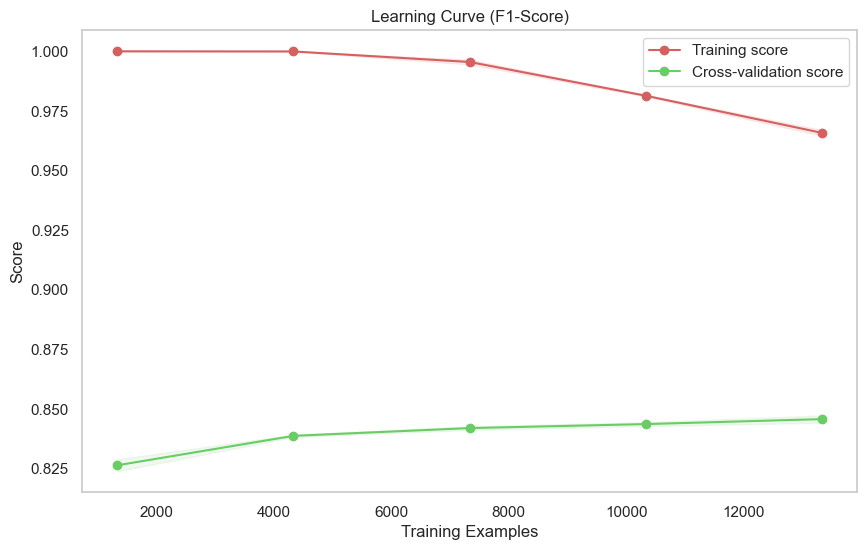

In [3]:
def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, scoring='f1', n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=42
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.title("Learning Curve (F1-Score)")
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.grid()
    
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    plt.legend(loc="best")
    plt.show()

# Per velocità, usiamo un sottoinsieme se il DF è enorme
indices = np.random.choice(X_train.index, size=min(20000, len(X_train)), replace=False)
plot_learning_curve(voting_model, X_train.loc[indices], y_train.loc[indices])

## 4. Ottimizzazione Soglia & CV
Usiamo `cross_val_predict` per ottenere probabilità pulite e ottimizzare la soglia per F0.7.

⏳ Computing OOF Probabilities (CV 5-Fold)...

🏆 Best Threshold (F0.7): 0.55
   Expected Score: 0.8469


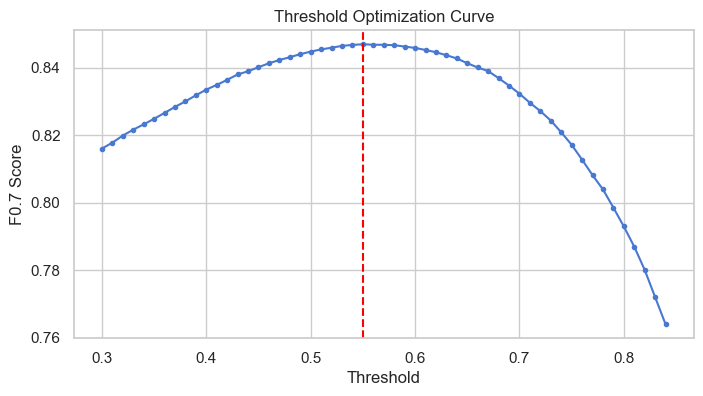

In [4]:
print("⏳ Computing OOF Probabilities (CV 5-Fold)...")
y_proba_cv = cross_val_predict(
    voting_model, 
    X_train, 
    y_train, 
    cv=5, 
    method='predict_proba',
    n_jobs=-1
)[:, 1]

thresholds = np.arange(0.3, 0.85, 0.01)
scores = [fbeta_score(y_train, (y_proba_cv >= t).astype(int), beta=0.7) for t in thresholds]
best_threshold = thresholds[np.argmax(scores)]

print(f"\n🏆 Best Threshold (F0.7): {best_threshold:.2f}")
print(f"   Expected Score: {max(scores):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, scores, marker='o', markersize=3)
plt.axvline(best_threshold, color='red', linestyle='--')
plt.title("Threshold Optimization Curve")
plt.xlabel("Threshold")
plt.ylabel("F0.7 Score")
plt.show()

## 5. Error Analysis (Validation)
Dove sbaglia il modello in validazione? Analizziamo la matrice di confusione alla soglia ottima.

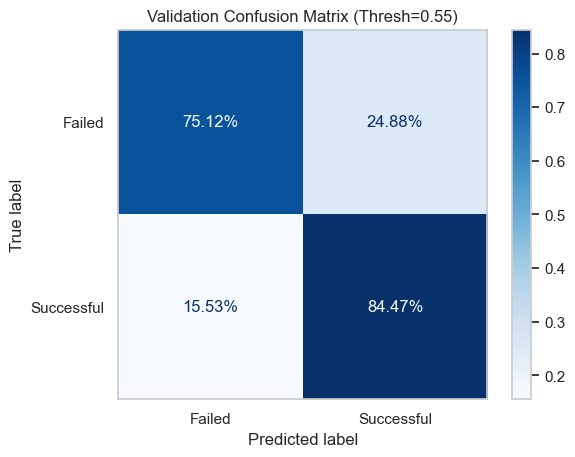

              precision    recall  f1-score   support

           0       0.75      0.75      0.75     56935
           1       0.85      0.84      0.85     93556

    accuracy                           0.81    150491
   macro avg       0.80      0.80      0.80    150491
weighted avg       0.81      0.81      0.81    150491



In [5]:
y_pred_cv = (y_proba_cv >= best_threshold).astype(int)

cm = confusion_matrix(y_train, y_pred_cv, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failed', 'Successful'])
disp.plot(cmap='Blues', values_format='.2%')
plt.title(f"Validation Confusion Matrix (Thresh={best_threshold:.2f})")
plt.grid(False)
plt.show()

print(classification_report(y_train, y_pred_cv))